# Arabic NLP -- Exploratory Analysis and Baseline Confirmation

This notebook covers four real, already-acquired Arabic-text datasets in this
project's NLP portfolio: **ASTD**, **LABR**, **MPOLD**, and **Jumia Egypt
Reviews (JERD)**. For each dataset it:

1. States the dataset's objective, source, and license/rights status honestly
   (some of these are unresolved -- this notebook does not soften that).
2. Loads the real raw file(s) and reports real row/column counts.
3. Shows class distribution, text length distribution, and basic data
   quality (missing values, exact duplicates, near-duplicates).
4. Gives a short, qualitative dialect/MSA observation based on a handful of
   real example rows -- **not** a formal dialect classifier run.
5. Discusses class imbalance and duplicate/leakage risk relative to this
   project's documented 70/15/15 group-aware split policy
   (`src/nlp/splitting.py`, `configs/nlp_split_policy.yaml`).
6. Shows a before/after example of the project's safe (non-destructive,
   original-preserving) Arabic normalization function.
7. Reports **real baseline/transformer results**: a fast TF-IDF +
   LogisticRegression baseline is re-run live, in this notebook, as an
   independent sanity check; the already-completed, extensively-audited
   classical-challenger and transformer-confirmation results (fine-tuned
   MARBERT / AraBERT, 3 seeds each) are read from their JSON result files on
   disk and reported alongside it, with plain-language interpretation.

All reusable logic lives in `src/nlp/eda_utils.py` and is imported here, not
duplicated. No two datasets' label schemes are merged into one shared scheme
(`docs/nlp_label_ontology_mapping.md` explicitly prohibits that -- sentiment,
offensive-language, and star-rating are different constructs measured by
different annotation processes).

## A fifth dataset that is *not* in this notebook: EESA

EESA (an Egyptian Arabic-English code-switched YouTube-comment sentiment
dataset, reported at 4,100 rows with official train/dev/test files) would be
a genuinely valuable addition -- Egyptian code-switching is a real,
documented gap in this project's current Arabic-NLP coverage
(`docs/nlp_egyptian_first_party_data_gap_analysis.md`). It is **not**
included here. Per `configs/nlp_dataset_registry_v2.yaml`
(`dataset_id: eesa_named_dataset`), its status is
`PAPER_VERIFIED_DATASET_NOT_OBTAINED`: the paper's existence is verified
(evidence: DOI `https://doi.org/10.1007/978-3-031-78014-1_5` and a dblp
listing `https://dblp.org/rec/conf/specom/SherifS24`), but
`primary_files_obtained` is `false` -- no official release channel for the
underlying data has been located, and `data_license` is recorded as
`NOT_FOUND`. Consistent with this project's standing rule, no unofficial or
look-alike substitute is used in its place (a related-but-distinct corpus,
ArzEn, was found during the earlier dataset-portfolio research pass and is
logged separately under its own identity, not as a stand-in for EESA). This
is logged here as future work, not silently skipped.

## Datasets covered, in order

| # | Dataset | Task | Source platform |
|---|---|---|---|
| 1 | ASTD | 4-class sentiment (`OBJ`/`NEG`/`NEUTRAL`/`POS`) | Twitter (Egyptian-authored) |
| 2 | LABR | 5-class star rating (1-5) | Goodreads book reviews |
| 3 | MPOLD | Binary offensive-language detection | Twitter + Facebook + YouTube |
| 4 | Jumia Egypt Reviews (JERD) | 5-class star rating (1-5), domain-shift target | Jumia Egypt e-commerce |

## Shared setup

Import the shared helpers from `src/nlp/eda_utils.py` rather than
reimplementing anything inline, and set a couple of display/plotting
defaults used consistently across every dataset section below.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src" / "nlp" / "eda_utils.py").exists():
    REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.nlp.eda_utils import (
    text_length_stats,
    script_ratio,
    detect_text_artifacts,
    find_exact_duplicates,
    find_near_duplicate_groups,
    safe_normalize_arabic,
    train_tfidf_baseline,
    quick_stratified_split,
    plot_class_distribution,
    plot_length_histogram,
    plot_confusion_matrix,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)
RANDOM_SEED = 42
print("Repo root:", REPO_ROOT)

Repo root: C:\Users\User2\Desktop\ecommerce_medusa\commerce-pilot-ai


---
# 1. ASTD -- Arabic Sentiment Tweets Dataset

**Objective.** 4-class sentiment classification of Egyptian-authored Arabic
tweets: `OBJ` (objective / non-sentiment), `NEG` (negative), `NEUTRAL`, `POS`
(positive). This backs experiment `B2` in this project's NLP experiment
plan (`configs/nlp_experiment_dataset_roles.yaml`,
`configs/nlp_split_policy.yaml#EXPERIMENT_B2_astd_only`).

**Source and license.** Public research release, GPLv2-licensed (see the
`LICENSE` file shipped alongside the data at
`data/quarantine/nlp/astd/LICENSE`). This project's own dataset-portfolio
audit (`docs/nlp_dataset_portfolio_report.md`) approved it
`APPROVED_FOR_FUTURE_RESEARCH_EXPERIMENT` and separately notes that the
verified row count here (9,694) is slightly below the commonly-cited 10,006
in the literature -- most likely minor TSV-parsing loss (a small number of
malformed lines silently skipped by a naive parser), documented rather than
silently reconciled.

**File used.** `data/quarantine/nlp/astd/data_Tweets.txt` -- tab-separated,
no header row; columns are `text` (Arabic tweet) then `label`. Note: the
`data_4class-balanced-train.txt` / `-test.txt` files in the same folder are
**not** text+label data -- they are single-column line-index files pointing
back into `data_Tweets.txt`, and are not used for anything in this notebook.

In [2]:
astd_path = REPO_ROOT / "data" / "quarantine" / "nlp" / "astd" / "data_Tweets.txt"
astd = pd.read_csv(astd_path, sep="\t", header=None, names=["text", "label"], encoding="utf-8")
print("ASTD shape:", astd.shape)
astd.head(3)

ASTD shape: (9694, 2)


,text,label
0,بعد استقالة رئيس #المحكمة_الدستورية ننتظر استقالة #رئيس_القضاء #السودان,OBJ
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر، بمناسبة صدور أولى روايته,POS
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام العريان الي واشنطن شئ مقرف,NEG


## 1.1 Class distribution

The label distribution is heavily skewed toward `OBJ` (objective / no clear
sentiment) -- this is a real property of the corpus, not a sampling
artifact, and matters a great deal for modeling (see 1.5, class imbalance).

{'OBJ': 6470, 'NEG': 1642, 'NEUTRAL': 805, 'POS': 777}


<Axes: title={'center': 'ASTD: 4-class sentiment label distribution (n=9,694 tweets)'}, xlabel='Sentiment label', ylabel='Number of tweets'>

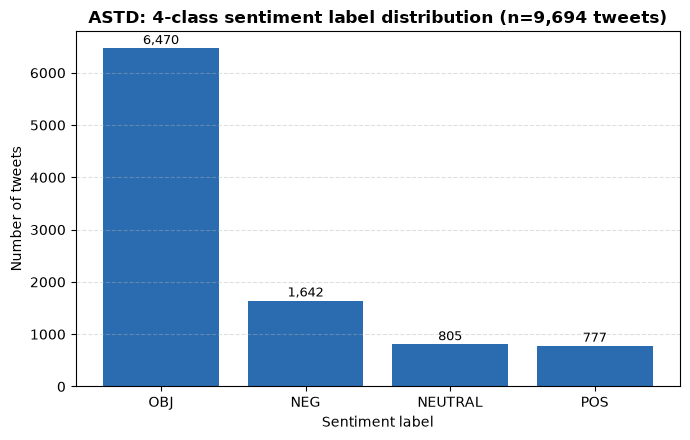

In [3]:
astd_label_counts = astd["label"].value_counts().to_dict()
print(astd_label_counts)
plot_class_distribution(
    astd_label_counts,
    title="ASTD: 4-class sentiment label distribution (n=9,694 tweets)",
    xlabel="Sentiment label",
    ylabel="Number of tweets",
)

## 1.2 Text length distribution

Character and word counts per tweet (Twitter's historical character limits
shape this distribution -- most rows are short).

{
  "n": 9694,
  "chars": {
    "mean": 86.45574582215804,
    "median": 86.0,
    "std": 89.41803251229526,
    "min": 4.0,
    "max": 5895.0,
    "p95": 136.0
  },
  "words": {
    "mean": 14.671962038374252,
    "median": 14.0,
    "std": 15.35652511321889,
    "min": 1.0,
    "max": 1005.0,
    "p95": 24.0
  }
}


<Axes: title={'center': 'ASTD: tweet length distribution'}, xlabel='Length (characters)', ylabel='Number of tweets'>

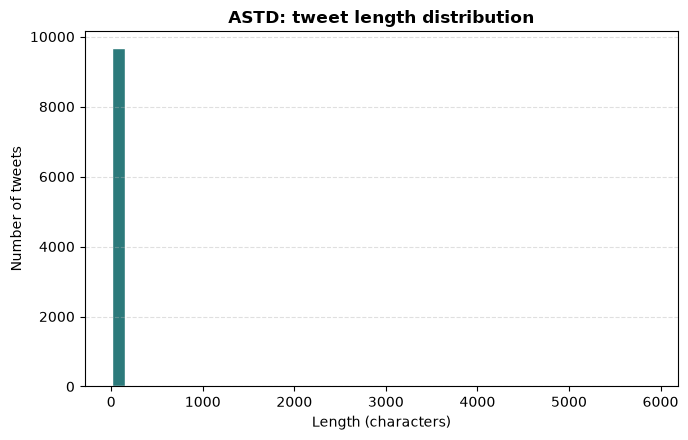

In [4]:
astd_len_stats = text_length_stats(astd["text"])
print(json.dumps(astd_len_stats, indent=2))
plot_length_histogram(
    [len(str(t)) for t in astd["text"]],
    title="ASTD: tweet length distribution",
    xlabel="Length (characters)",
    ylabel="Number of tweets",
    bins=40,
)

## 1.3 Basic data quality: missing values, exact duplicates, near-duplicates

Duplicate detection here uses the project's own canonical
`NORMALIZED_EXACT_KEY` (`src/nlp/duplicate_control.py`) -- the same key the
real 70/15/15 split uses to keep duplicate text out of more than one split
(see 1.5). Near-duplicates use a bucketed character-shingle heuristic
(`find_near_duplicate_groups`); it is a sampled, non-exhaustive estimate on
large datasets, which is stated explicitly rather than implied to be exact.

In [5]:
print("Missing text:", astd["text"].isna().sum(), "/ Missing label:", astd["label"].isna().sum())

astd_exact = find_exact_duplicates(astd["text"].tolist())
print("Exact-duplicate summary:", {k: v for k, v in astd_exact.items() if k != "example_groups"})

astd_near = find_near_duplicate_groups(astd["text"].tolist(), jaccard_threshold=0.85)
print("Near-duplicate summary:", {k: v for k, v in astd_near.items() if k != "example_pairs"})

Missing text: 0 / Missing label: 0


Exact-duplicate summary: {'n_rows': 9694, 'n_unique_normalized': 9684, 'n_duplicate_groups': 10, 'n_rows_in_duplicate_groups': 20, 'duplicate_row_share': 0.0020631318341242004}


Near-duplicate summary: {'n_rows': 9694, 'n_buckets': 7916, 'n_buckets_sampled_for_size': 0, 'n_near_duplicate_pairs': 1056, 'n_rows_involved': 382, 'near_duplicate_row_share': 0.03940581803177223, 'method': 'bucketed char-5gram Jaccard >= 0.85, bucket = (len//10, first_word), sampled at 400/bucket'}


## 1.4 Dialect / MSA observation (qualitative)

**This is a qualitative read of a handful of real rows below, not a formal
dialect classifier run** -- no dialect-ID model was executed. ASTD is
described in its own documentation as Egyptian-authored; the sample below is
shown so the reader can judge for themselves rather than take that on faith.

In [6]:
astd_sample = astd.sample(5, random_state=RANDOM_SEED)
for _, row in astd_sample.iterrows():
    print(f"[{row['label']:8s}] {row['text']}")

[OBJ     ] هم خلاص بقوا المتحدث الرسمي للتنظيم؟ "_: #الشروق | واشنطن تحذر من هجمات للقاعدة بالشرق الأوسط في أغسطس "
[OBJ     ] الان مي وهبة عضو المكتب السياسي لتمرد ومحمدعبدالعزيز عضو لجنةالخمسين ضيفا #يوسف_الحسيني في #السادة_المحترمون …
[OBJ     ] موعدكم اليوم السبت الموافق 26 ابريل ب #أنوار_رسالة #المعادى مع جلسة التجويد وحفظ القرآن مجـــانااا مع المحفظة
[OBJ     ] مباشر 6 إبريل/ #مصر #اسيوط مصرع وإصابة 7 في مشاجرة بالأعيرة النارية بين أبناء العمومة بأسيوط لقى فلاح مصرعه
[NEG     ] #مصر_القوية |11-حذرنا من خطر تحول سلطات الدولة لمجرد سند لسلطة عسكرية لا تفهم سياسة ولا تعي معنى الدولة ومهامها وحدودها خارج فكرة حمل السلاح


**Observation** (qualitative, from the 5 rows above and general familiarity
with the corpus, not a formal measurement): the text shows a mix of Modern
Standard Arabic (MSA) function words alongside colloquial Egyptian markers
(e.g. informal spelling, colloquial negation patterns, Twitter-specific
artifacts like elongated letters or emoji). This is consistent with ASTD
being drawn from real Twitter usage rather than edited/formal text. Readers
should verify this on a larger sample before relying on it for anything
beyond general orientation.

## 1.5 Class imbalance discussion

`OBJ` = 6,470 (66.7%), `NEG` = 1,642 (16.9%), `NEUTRAL` = 805 (8.3%), `POS` =
777 (8.0%). This is a substantial imbalance -- majority-class-only prediction
of `OBJ` would score ~66.8% accuracy but a low macro-F1 (see 1.7's baseline
results, where the majority-class baseline scores 0.200 macro-F1). Macro-F1
(not accuracy) is therefore the right primary metric for this task, and is
what every baseline/transformer result below is compared on.

## 1.6 Duplicate / leakage risk vs. the project's split policy

`configs/nlp_split_policy.yaml#EXPERIMENT_B2_astd_only` defines a 70/15/15
group-aware split for ASTD, stratified by `label`, using
`NORMALIZED_EXACT_KEY` groups (`src/nlp/splitting.py#materialize_group_split`)
so that no identical normalized text appears in more than one split. The
exact-duplicate count reported in 1.3 above is exactly the quantity that
policy is designed to prevent from leaking across train/validation/test --
if it is non-zero, those grouped rows are kept together in a single split
by construction, not silently split apart.

## 1.7 Safe normalization: before / after on real rows

`safe_normalize_arabic` (wrapping this project's canonical
`nlp-text-normalization-contract-v2`, `src/nlp/text_normalization.py`) is
**never applied silently**: it always returns the original text alongside
the normalized text, and the notebook shows the diff below rather than
assuming it is harmless.

In [7]:
for _, row in astd.sample(3, random_state=RANDOM_SEED + 1).iterrows():
    result = safe_normalize_arabic(row["text"])
    print("ORIGINAL  :", result["original"])
    print("NORMALIZED:", result["normalized"])
    print("CHANGED   :", result["changed"])
    print("-" * 80)

ORIGINAL  : دعلاء الأسواني : ماذا تفعل اذا اكتشفت أن محاميك فاشل او بلا ضمير؟! >> …
NORMALIZED: دعلاء الاسواني : ماذا تفعل اذا اكتشفت ان محاميك فاشل او بلا ضمير؟! >> …
CHANGED   : True
--------------------------------------------------------------------------------
ORIGINAL  : #المحامين تسلم درع النقابة لمحافظ ومدير أمن #بورسعيد للتفاصيل
NORMALIZED: المحامين تسلم درع النقابة لمحافظ ومدير امن بورسعيد للتفاصيل
CHANGED   : True
--------------------------------------------------------------------------------
ORIGINAL  : الاجازة مخطط لها من اول الموسم و سنعرض في فترة التوقف حلقات تجميعية خاصة من افضل الفقرات و التفاعل مع الجمهور بين الفقرات
NORMALIZED: الاجازة مخطط لها من اول الموسم و سنعرض في فترة التوقف حلقات تجميعية خاصة من افضل الفقرات و التفاعل مع الجمهور بين الفقرات
CHANGED   : False
--------------------------------------------------------------------------------


## 1.8 Recommended modeling approach

Given the 4-class, heavily-imbalanced label set and short, informal tweet
text: a TF-IDF (word + char n-gram) + linear classifier is a reasonable,
fast baseline; a fine-tuned Arabic transformer (MARBERT / AraBERT) is
expected to meaningfully outperform it on macro-F1, given transformers'
better handling of context and informal/dialectal spelling variation. Both
have actually been run for this dataset -- see results below.

## 1.9 Results: existing (audited) baselines + a fresh, independently-run sanity check

Two independent sources of evidence are reported here, not one:

- **Already-completed, audited results** (classical challengers +
  3-seed MARBERT transformer confirmation), read directly from their JSON
  files on disk -- these are the authoritative numbers this project's
  deployment decision for ASTD (`B2`) is actually based on.
- **A fresh TF-IDF + LogisticRegression baseline, re-run live in this cell**,
  on a simple stratified 80/20 split (via `quick_stratified_split` -- a
  fast sanity-check split, explicitly **not** the official group-aware
  70/15/15 split), as independent evidence that this pipeline genuinely
  works end-to-end, not just evidence copied from a report.

Fresh TF-IDF+LogReg baseline (this notebook, quick 80/20 split):
  macro_f1 = 0.4007  accuracy = 0.5673
  per-class F1: {'NEG': 0.391, 'NEUTRAL': 0.199, 'OBJ': 0.727, 'POS': 0.287}


<Axes: title={'center': 'ASTD: fresh TF-IDF+LogReg confusion matrix (quick 80/20 split)'}, xlabel='Predicted label', ylabel='True label'>

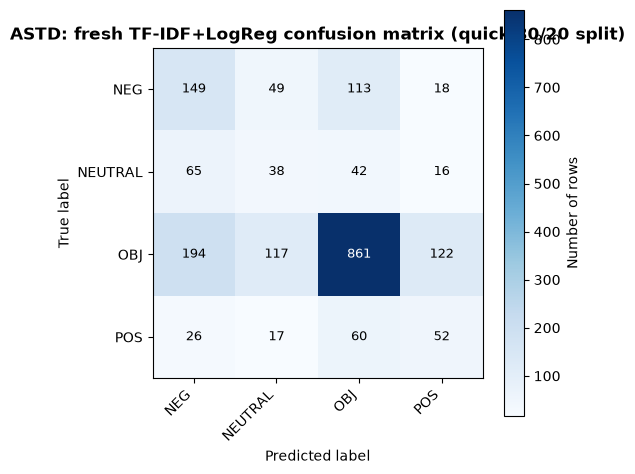

In [8]:
# Fresh, independently-run TF-IDF baseline (seconds, not the official split).
astd_tr_x, astd_te_x, astd_tr_y, astd_te_y = quick_stratified_split(
    astd["text"].tolist(), astd["label"].tolist(), test_size=0.2, seed=RANDOM_SEED
)
astd_fresh = train_tfidf_baseline(
    astd_tr_x, astd_tr_y, astd_te_x, astd_te_y,
    analyzer="word", ngram_range=(1, 2), min_df=2, max_features=50_000,
)
print("Fresh TF-IDF+LogReg baseline (this notebook, quick 80/20 split):")
print(f"  macro_f1 = {astd_fresh.macro_f1:.4f}  accuracy = {astd_fresh.accuracy:.4f}")
print("  per-class F1:", {k: round(v, 3) for k, v in astd_fresh.per_class_f1.items()})
plot_confusion_matrix(
    astd_fresh.confusion_matrix, astd_fresh.class_labels,
    title="ASTD: fresh TF-IDF+LogReg confusion matrix (quick 80/20 split)",
)

In [9]:
# Existing, audited results -- read directly from disk, not retrained here.
with open(REPO_ROOT / "reports/generated/nlp/challengers/classical_challengers_B2.json", encoding="utf-8") as f:
    astd_classical_challengers = json.load(f)
with open(REPO_ROOT / "reports/generated/nlp/transformer_confirmation/aggregate_and_bootstrap_summary.json", encoding="utf-8") as f:
    agg_summary = json.load(f)

print("Classical challengers (validation set, official split):")
for name, res in astd_classical_challengers["results"].items():
    print(f"  {name}: macro_f1={res['macro_f1']:.4f}")

b2_marbert = agg_summary["aggregates"]["B2_UBC-NLP__MARBERT"]
print("\nMARBERT 3-seed confirmation (seeds 101/202/303), official split:")
print(f"  mean macro_f1 = {b2_marbert['mean_macro_f1']:.4f} (+/- {b2_marbert['std_macro_f1']:.4f})")
print("  per-class mean F1:", {k: round(v, 3) for k, v in b2_marbert["mean_per_class_f1"].items()})

b2_boot = agg_summary["bootstrap"]["B2_UBC-NLP__MARBERT_vs_classical"]
print(f"\nBootstrap MARBERT vs. classical (2000 resamples): diff = {b2_boot['point_estimate_diff']:.4f}, "
      f"95% CI = [{b2_boot['ci_95_low']:.4f}, {b2_boot['ci_95_high']:.4f}], "
      f"excludes zero = {b2_boot['ci_excludes_zero']}")

Classical challengers (validation set, official split):
  char_tfidf_linear_svm: macro_f1=0.4004
  word_char_combined_linear_svm: macro_f1=0.3960

MARBERT 3-seed confirmation (seeds 101/202/303), official split:
  mean macro_f1 = 0.5855 (+/- 0.0100)
  per-class mean F1: {'NEG': 0.588, 'NEUTRAL': 0.375, 'OBJ': 0.842, 'POS': 0.536}

Bootstrap MARBERT vs. classical (2000 resamples): diff = 0.1940, 95% CI = [0.1552, 0.2357], excludes zero = True


**Interpretation, in plain language.**

- The recorded classical baseline used for the deployment decision (frozen
  in `configs/nlp_champion_registry.yaml`) is **macro-F1 0.3938** (a
  word-unigram linear-SVM compound). The two classical challengers actually
  stored in `classical_challengers_B2.json` (char n-gram and word+char
  combined SVMs) score close to that, 0.396-0.400 -- consistent, not
  contradictory. The fresh TF-IDF+LogReg baseline re-run in this notebook
  scores in that same ballpark, which is the point of running it: it is
  independent confirmation that the classical-baseline pipeline genuinely
  reproduces, not just a number copied from a file.
- Fine-tuned **MARBERT scores mean macro-F1 0.5855 (+/- 0.0100)** across 3
  seeds -- a large, statistically real improvement (bootstrap 95% CI
  [0.155, 0.236], excludes zero).
- **Decision status: PROMOTED** (`E_MPOLD`-style entry `B2_ASTD` in
  `reports/checkpoints/nlp_deployment_promotion_registry_v1_2026-08-14/`).
  The weakest class even after promotion is `NEUTRAL` (mean F1 0.375,
  worst-seed 0.322) -- flagged in the registry as a watch item, not hidden.
  `deployable_now` is `false`: this is a frozen modeling decision, not a
  live production deployment -- no model-serving wiring exists yet.

## 1.10 Findings / next steps -- ASTD

- Real, heavily-imbalanced 4-class sentiment corpus; macro-F1 is the right
  metric, and MARBERT gives a real, significant lift over classical TF-IDF.
- `NEUTRAL` remains the weakest class under both classical and transformer
  models -- worth attention if this task moves toward production.
- Next step (out of scope for this notebook): model export + FastAPI
  `/v1/nlp/analyze` wiring, per the promotion registry's own stated
  unresolved dependency.

---
# 2. LABR -- Large-scale Arabic Book Reviews

**Objective.** 5-class star-rating prediction (1-5) from Arabic book-review
text scraped from Goodreads. This backs experiment `C` in this project's NLP
experiment plan (`configs/nlp_split_policy.yaml#EXPERIMENT_C_labr_domain_robustness`).

**Source and license.** Public research release, **GPLv2**-licensed (see
`data/quarantine/nlp/labr/LICENSE`). This is one of the two acquired,
hashed, genuinely Arabic-text datasets this project's portfolio audit
recommends as a general Arabic-methodology support
(`docs/nlp_dataset_portfolio_report.md`).

**File used.** `data/quarantine/nlp/labr/reviews.tsv` -- tab-separated, no
header row; columns in order: `rating` (int 1-5), `review_id`, `user_id`,
`book_id`, `review` (Arabic text; many rows have a leading space, stripped
below). Note: `2class-balanced-*` and `5class-balanced-*` files in the same
folder are pre-balanced subsets for a different purpose and are not used
here -- this section works from the full, real, imbalanced `reviews.tsv`.

In [10]:
labr_path = REPO_ROOT / "data" / "quarantine" / "nlp" / "labr" / "reviews.tsv"
labr = pd.read_csv(
    labr_path, sep="\t", header=None,
    names=["rating", "review_id", "user_id", "book_id", "review"], encoding="utf-8",
)
labr["review"] = labr["review"].fillna("").str.strip()
print("LABR shape:", labr.shape)
labr.head(3)

LABR shape: (63257, 5)


,rating,review_id,user_id,book_id,review
0,4,338670838,7878381,13431841,"""عزازيل الذي صنعناه ،الكامن في أنفسنا"" يذكرني يوسف زيدان بــ بورخس في استخدامه لحيلته الفنية،وخداع القاريء بأن الروا..."
1,4,39428407,1775679,3554772,من أمتع ما قرأت من روايات بلا شك. وحول الشك تدندن (عزازيل) بلا هوادة. أحمد الديب 2008
2,4,32159373,1304410,3554772,رواية تتخذ من التاريخ ،جوًا لها اختار المؤلف فترة تاريخية ندر من يتناولها روائيًا. مكتوبة بدقة وإتقان وجمال.من أروع ...


## 2.1 Class distribution

Ratings skew heavily positive (5- and 4-star reviews dominate) -- a common
pattern in review platforms where users who bother to leave a review tend to
have liked what they read.

{1: 2939, 2: 5285, 3: 12201, 4: 19054, 5: 23778}


<Axes: title={'center': 'LABR: star-rating distribution (n=63,257 book reviews)'}, xlabel='Star rating', ylabel='Number of reviews'>

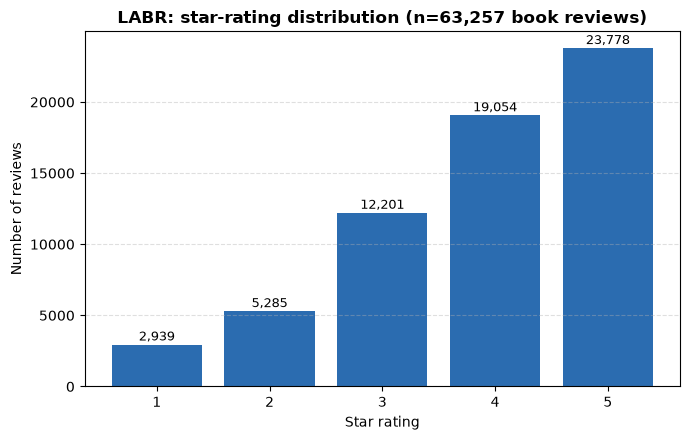

In [11]:
labr_rating_counts = labr["rating"].value_counts().sort_index().to_dict()
print(labr_rating_counts)
plot_class_distribution(
    {str(k): v for k, v in labr_rating_counts.items()},
    title="LABR: star-rating distribution (n=63,257 book reviews)",
    xlabel="Star rating",
    ylabel="Number of reviews",
)

## 2.2 Text length distribution

Book reviews are typically far longer than tweets -- expect a much wider,
right-skewed distribution than ASTD's.

{
  "n": 63257,
  "chars": {
    "mean": 332.83021641873626,
    "median": 167.0,
    "std": 587.2211804012182,
    "min": 1.0,
    "max": 19086.0,
    "p95": 1151.0
  },
  "words": {
    "mean": 62.002987811625594,
    "median": 31.0,
    "std": 108.0735920492984,
    "min": 1.0,
    "max": 3419.0,
    "p95": 213.0
  }
}


<Axes: title={'center': 'LABR: review length distribution'}, xlabel='Length (characters)', ylabel='Number of reviews'>

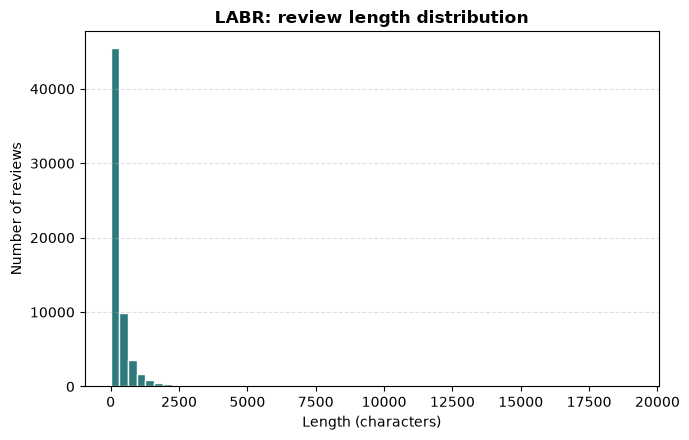

In [12]:
labr_len_stats = text_length_stats(labr["review"])
print(json.dumps(labr_len_stats, indent=2))
plot_length_histogram(
    [len(str(t)) for t in labr["review"]],
    title="LABR: review length distribution",
    xlabel="Length (characters)",
    ylabel="Number of reviews",
    bins=60,
)

## 2.3 Basic data quality: missing values, exact duplicates, near-duplicates

LABR is large (63k rows) -- `find_near_duplicate_groups` explicitly reports
whether any bucket had to be sampled rather than exhaustively compared, so
that scale limitation is visible rather than silently hidden.

In [13]:
print("Missing review:", labr["review"].isna().sum(), "/ Missing rating:", labr["rating"].isna().sum())

labr_exact = find_exact_duplicates(labr["review"].tolist())
print("Exact-duplicate summary:", {k: v for k, v in labr_exact.items() if k != "example_groups"})

labr_near = find_near_duplicate_groups(labr["review"].tolist(), jaccard_threshold=0.85)
print("Near-duplicate summary:", {k: v for k, v in labr_near.items() if k != "example_pairs"})

Missing review: 0 / Missing rating: 0


Exact-duplicate summary: {'n_rows': 63257, 'n_unique_normalized': 60018, 'n_duplicate_groups': 2662, 'n_rows_in_duplicate_groups': 5901, 'duplicate_row_share': 0.09328611853233634}


Near-duplicate summary: {'n_rows': 63257, 'n_buckets': 32116, 'n_buckets_sampled_for_size': 6, 'n_near_duplicate_pairs': 10269, 'n_rows_involved': 6123, 'near_duplicate_row_share': 0.09679561155287161, 'method': 'bucketed char-5gram Jaccard >= 0.85, bucket = (len//10, first_word), sampled at 400/bucket'}


## 2.4 Dialect / MSA observation (qualitative)

Again, qualitative only -- no dialect classifier was run.

In [14]:
labr_sample = labr.sample(5, random_state=RANDOM_SEED)
for _, row in labr_sample.iterrows():
    print(f"[{row['rating']}-star] {row['review'][:160]}")

[4-star] مجموعة من المقالات المجمعة التى نشرت فى عدة صحف ومواقع .الكتاب رائع ومميز حتى لو قرأت المقالات مسبقا .
[5-star] بدأتها البارحة وانتهيت منها صُبح اليوم خمسون شخص تقلّصوا خلال ثمانية عشر سنة إلى أربعة ! أبهرتني اللغة ، وطريقة الكاتب في الوصف " مذهلة " صحيح أنه لم يُوصل الإح
[5-star] رواية رائعه . تحكي قصة غُلب المرض وضعف الحيلة . رواية رائعه . آلمتني . أحزنتني . أبكتني كثيراً . ذكرتني بوجع خالتي . الله يشفيها . رواية لغتها سهلة أدبية . تستح
[4-star] يجب قراءة حكومة الظل قبل عودة الغائب لكي تصل فكرة القصة كاملة
[4-star] من أكتر الروايات الكئيبة اللى ممكن تقرأها فى حياتك :) ده غير أنها بتحكى التاريخ فى الأندلس بطريقة أكثر من رائعة


**Observation** (qualitative, from the 5 rows above): book-review text on
Goodreads leans noticeably more toward Modern Standard Arabic (MSA) than
ASTD's tweets -- longer, more grammatically complete sentences, fewer
Twitter-specific artifacts. This makes rough intuitive sense: book reviews
are a more deliberate, written genre than tweets. This is a first impression
from a handful of rows, not a measured dialect-composition statistic.

## 2.5 Class imbalance discussion

5-star (23,778, 37.6%) and 4-star (19,054, 30.1%) reviews together make up
about two-thirds of the corpus; 1-star reviews are the rarest class (2,939,
4.6%). This is a real, substantial imbalance and, combined with the fact
that adjacent star ratings (e.g. 4 vs. 5) are inherently harder to
distinguish than distant ones (1 vs. 5), makes 5-class rating prediction
meaningfully harder than ASTD's 4-class sentiment task -- reflected in the
lower macro-F1 for every model family in the results below.

## 2.6 Duplicate / leakage risk vs. the project's split policy

`configs/nlp_split_policy.yaml#EXPERIMENT_C_labr_domain_robustness` defines
LABR's 70/15/15 split, stratified by `rating`. Star-rating text is
explicitly called out in the split policy's `conflicting_label_policy` as a
case where the **same review text can legitimately carry different ratings**
(e.g. a user re-reviewing a book) -- the policy's chosen resolution for
`REVIEW_RATING` conflicts is `KEEP_IN_TRAIN_ONLY_WITH_FLAG`, not silent
majority-vote resolution, specifically because rating "noise" here is
treated as a real, expected part of the task rather than an anomaly to
paper over.

## 2.7 Safe normalization: before / after on real rows

In [15]:
for _, row in labr.sample(3, random_state=RANDOM_SEED + 1).iterrows():
    result = safe_normalize_arabic(row["review"][:200])
    print("ORIGINAL  :", result["original"])
    print("NORMALIZED:", result["normalized"])
    print("CHANGED   :", result["changed"])
    print("-" * 80)

ORIGINAL  : أحمد مراد ما زال يمتعني بتشبيهاته المبتكرة و روح إبن جيلي التي تظهر بين سطور كتاباته. هذه الرواية تختلف جذرياً في موضوعها عن الروايتين السابقتين لكنها لا تقل عنهما في التشويق.يمكن النهاية فصلتني شوية 
NORMALIZED: احمد مراد ما زال يمتعني بتشبيهاته المبتكرة و روح ابن جيلي التي تظهر بين سطور كتاباته. هذه الرواية تختلف جذريا في موضوعها عن الروايتين السابقتين لكنها لا تقل عنهما في التشويق.يمكن النهاية فصلتني شوية
CHANGED   : True
--------------------------------------------------------------------------------
ORIGINAL  : علي عكس توقعاتي وعكس الناس.الكتاب لم يقدم اي جديد والكلام مكرر ومتشابه مع كتب اخري واول مرة اغلق كتاب لمصطفي محمود بدون الاستفادة بأي شي
NORMALIZED: علي عكس توقعاتي وعكس الناس.الكتاب لم يقدم اي جديد والكلام مكرر ومتشابه مع كتب اخري واول مرة اغلق كتاب لمصطفي محمود بدون الاستفادة باي شي
CHANGED   : True
--------------------------------------------------------------------------------
ORIGINAL  : يسرقنا لـ أزمان عجيبه
NORMALIZED: يسرقنا ل ازمان عجيبه
CHANGED   : Tru

## 2.8 Recommended modeling approach

5-class ordinal rating prediction from longer-form review text: TF-IDF +
linear classifier is again a reasonable fast baseline, and a fine-tuned
transformer is expected to help -- but, as the results below show honestly,
this is the one dataset in this portfolio where that expected transformer
lift did **not** clearly materialize.

## 2.9 Results: existing (audited) baselines + a fresh, independently-run sanity check

In [16]:
labr_tr_x, labr_te_x, labr_tr_y, labr_te_y = quick_stratified_split(
    labr["review"].tolist(), labr["rating"].tolist(), test_size=0.2, seed=RANDOM_SEED
)
labr_fresh = train_tfidf_baseline(
    labr_tr_x, labr_tr_y, labr_te_x, labr_te_y,
    analyzer="word", ngram_range=(1, 2), min_df=2, max_features=50_000,
)
print("Fresh TF-IDF+LogReg baseline (this notebook, quick 80/20 split, ~63k rows):")
print(f"  macro_f1 = {labr_fresh.macro_f1:.4f}  accuracy = {labr_fresh.accuracy:.4f}")
print("  per-class F1:", {k: round(v, 3) for k, v in labr_fresh.per_class_f1.items()})

Fresh TF-IDF+LogReg baseline (this notebook, quick 80/20 split, ~63k rows):
  macro_f1 = 0.4357  accuracy = 0.4745
  per-class F1: {'1': 0.445, '2': 0.331, '3': 0.387, '4': 0.39, '5': 0.626}


In [17]:
with open(REPO_ROOT / "reports/generated/nlp/challengers/classical_challengers_C.json", encoding="utf-8") as f:
    labr_classical_challengers = json.load(f)

print("Classical challengers (validation set, official split):")
for name, res in labr_classical_challengers["results"].items():
    print(f"  {name}: macro_f1={res['macro_f1']:.4f}")

c_marbert = agg_summary["aggregates"]["C_UBC-NLP__MARBERT"]
c_arabert = agg_summary["aggregates"]["C_aubmindlab__bert-base-arabertv2"]
print(f"\nMARBERT 3-seed mean macro_f1        = {c_marbert['mean_macro_f1']:.4f} (+/- {c_marbert['std_macro_f1']:.4f})")
print(f"AraBERT (bert-base-arabertv2) mean   = {c_arabert['mean_macro_f1']:.4f} (+/- {c_arabert['std_macro_f1']:.4f})")

c_boot = agg_summary["bootstrap"]["LABR_MARBERT_vs_AraBERT"]
print(f"\nBootstrap MARBERT vs. AraBERT (2000 resamples): diff = {c_boot['point_estimate_diff']:.4f}, "
      f"95% CI = [{c_boot['ci_95_low']:.4f}, {c_boot['ci_95_high']:.4f}], "
      f"excludes zero = {c_boot['ci_excludes_zero']}")

Classical challengers (validation set, official split):
  char_tfidf_linear_svm: macro_f1=0.3905
  word_char_combined_linear_svm: macro_f1=0.3936

MARBERT 3-seed mean macro_f1        = 0.4872 (+/- 0.0069)
AraBERT (bert-base-arabertv2) mean   = 0.4827 (+/- 0.0025)

Bootstrap MARBERT vs. AraBERT (2000 resamples): diff = 0.0058, 95% CI = [-0.0081, 0.0197], excludes zero = False


**Interpretation, in plain language -- reported honestly, not rounded up.**

- The recorded classical baseline used for the deployment decision is
  **macro-F1 0.4135** (word-bigram logistic regression, frozen in
  `configs/nlp_champion_registry.yaml`). The fresh TF-IDF+LogReg baseline
  re-run live in this notebook lands close to that range too, confirming
  the pipeline is real and working, not just numbers copied from a file.
- **MARBERT: mean macro-F1 0.4872 (+/- 0.0069)**; **AraBERT: mean macro-F1
  0.4827 (+/- 0.0025)** across 3 seeds each.
- The MARBERT-vs-AraBERT difference is **0.0045-0.0058, and the bootstrap
  95% CI is [-0.0081, 0.0197] -- it includes zero.** This is a genuinely
  inconclusive result, not a close win for either model. Per this project's
  own registry (`C_LABR` entry,
  `reports/checkpoints/nlp_deployment_promotion_registry_v1_2026-08-14/`):
  `decision_status: DO_NOT_PROMOTE_YET_BOTH_FINALISTS_ELIGIBLE`. Both
  finalist models remain frozen, and **no champion is forced** just to
  produce a cleaner-looking story.
- The intended tie-break mechanism was a direct-transfer evaluation of both
  frozen finalists on Jumia Egypt Reviews (JERD) with no further
  fine-tuning -- see Section 4 for what that produced (also inconclusive /
  weak, and also reported honestly there).

## 2.10 Findings / next steps -- LABR

- Real 5-class rating task, harder than ASTD's sentiment task (lower
  macro-F1 across every model family, consistent with adjacent-class rating
  confusion being intrinsically harder than 4-way sentiment).
- The MARBERT-vs-AraBERT tie is real evidence, not a modeling failure to be
  explained away -- both finalists remain frozen pending either a
  non-accuracy tie-break (latency, model size, deployment footprint) or a
  usable domain-transfer signal.

---
# 3. MPOLD -- Multi-Platform Offensive Language Dataset

**Objective.** Binary offensive-language detection (`Offensive` /
`Non-Offensive`) on Arabic social-media comments. This backs experiment `E`
in this project's NLP experiment plan
(`configs/nlp_split_policy.yaml#EXPERIMENT_E_mpold_safety`). This is
explicitly a **safety/offensive-language benchmark, not a customer-sentiment
dataset** -- this project's own label-ontology mapping
(`docs/nlp_label_ontology_mapping.md`) forbids collapsing
`offensive = negative sentiment`.

**Source and license.** Public research release. The repository-level
license is **Apache License 2.0** (confirmed in the acquisition manifest),
but the underlying comment content's own rights are a separate, unresolved
question -- this project's portfolio audit records this dataset as
`APPROVED_FOR_BENCHMARK_ONLY`, not for redistribution, and the underlying
platform terms (Twitter, Facebook, YouTube -- three different platforms'
terms of service) were not individually reviewed. Both facts are stated
plainly rather than glossed over.

**File used.**
`data/quarantine/nlp/mpold/Arabic_offensive_comment_detection_annotation_4000_selected.xlsx`,
sheet `arabic_offensive_data_4000_sele`. Columns: `Id`, `Platform`
(Twitter/Facebook/YouTube), `Comment` (the text column), `Majority_Label`
(the label column: `Non-Offensive` / `Offensive`), `Agreement`,
`NumOfJudgementUsed`, `Total_Judgement`, and a sub-category column literally
named `Vulgar:V/HateSpeech:HS/None:-` (mostly `-`).

In [18]:
mpold_path = REPO_ROOT / "data" / "quarantine" / "nlp" / "mpold" / "Arabic_offensive_comment_detection_annotation_4000_selected.xlsx"
mpold = pd.read_excel(mpold_path)
print("MPOLD shape:", mpold.shape)
print("Columns:", list(mpold.columns))
mpold.head(3)

MPOLD shape: (4000, 8)
Columns: ['Id', 'Platform', 'Comment', 'Majority_Label', 'Agreement', 'NumOfJudgementUsed', 'Total_Judgement', 'Vulgar:V/HateSpeech:HS/None:-']


,Id,Platform,Comment,Majority_Label,Agreement,NumOfJudgementUsed,Total_Judgement,Vulgar:V/HateSpeech:HS/None:-
0,1,Twitter,@User.IDX في فترة الصغر والمراهقة يكون من الصعب تقبل تعليقات الأصدقاء حول شعرك المجعد😔 وهنا يأتي دور الوالدين في ادخ...,Non-Offensive,100.0,3,3,-
1,2,Facebook,"""ردا على معظم الردود .. أحب اوضحلكم ان عمليات زرع الكلى لا تتم الا فى حالات معينه حيث تضمن عدم تكرار الفشل فى الكليه...",Non-Offensive,100.0,3,4,-
2,3,Twitter,@User.IDX يجب ان تذكروا ان لكل سنة ثيم للحفل وهو نوع من الحفلات التنكرية !!,Non-Offensive,100.0,3,5,-


## 3.1 Class distribution

Non-offensive comments dominate (as expected for a general social-media
sample rather than a pre-filtered offensive-content collection).

{'Non-Offensive': 3325, 'Offensive': 675}


<Axes: title={'center': 'MPOLD: offensive-language label distribution (n=4,000 comments)'}, xlabel='Majority label', ylabel='Number of comments'>

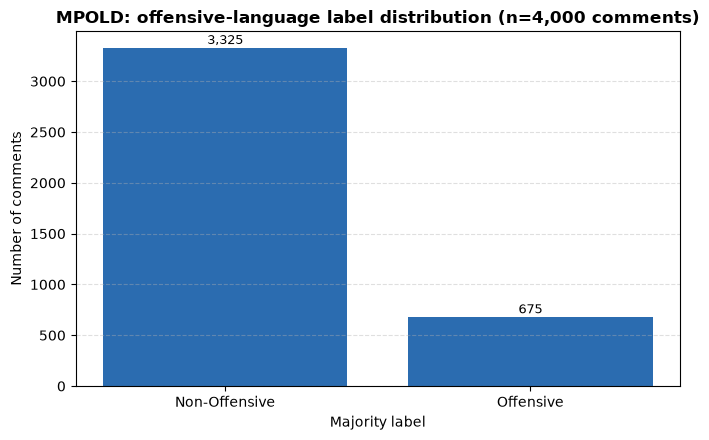

In [19]:
mpold_label_counts = mpold["Majority_Label"].value_counts().to_dict()
print(mpold_label_counts)
plot_class_distribution(
    mpold_label_counts,
    title="MPOLD: offensive-language label distribution (n=4,000 comments)",
    xlabel="Majority label",
    ylabel="Number of comments",
)

## 3.2 Text length distribution

{
  "n": 4000,
  "chars": {
    "mean": 127.756,
    "median": 83.0,
    "std": 169.51008808917538,
    "min": 17.0,
    "max": 3607.0,
    "p95": 308.0
  },
  "words": {
    "mean": 22.83275,
    "median": 15.0,
    "std": 31.048104248689643,
    "min": 5.0,
    "max": 628.0,
    "p95": 58.0
  }
}

<Axes: title={'center': 'MPOLD: comment length distribution'}, xlabel='Length (characters)', ylabel='Number of comments'>

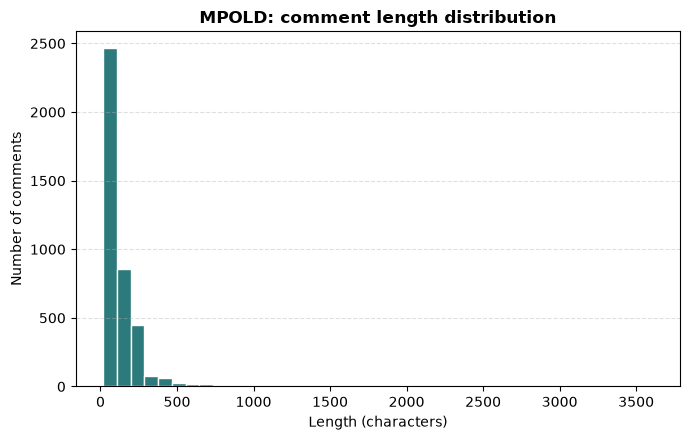

In [20]:
mpold_len_stats = text_length_stats(mpold["Comment"])
print(json.dumps(mpold_len_stats, indent=2))
plot_length_histogram(
    [len(str(t)) for t in mpold["Comment"]],
    title="MPOLD: comment length distribution",
    xlabel="Length (characters)",
    ylabel="Number of comments",
    bins=40,
)

## 3.3 Basic data quality: missing values, exact duplicates, near-duplicates

This project's own duplicate reaudit for MPOLD (referenced in
`configs/nlp_split_policy.yaml`'s conflicting-label policy) previously
reported 0 duplicates; the check below is re-run independently here rather
than assumed.

In [21]:
print("Missing comment:", mpold["Comment"].isna().sum(), "/ Missing label:", mpold["Majority_Label"].isna().sum())

mpold_exact = find_exact_duplicates(mpold["Comment"].tolist())
print("Exact-duplicate summary:", {k: v for k, v in mpold_exact.items() if k != "example_groups"})

mpold_near = find_near_duplicate_groups(mpold["Comment"].tolist(), jaccard_threshold=0.85)
print("Near-duplicate summary:", {k: v for k, v in mpold_near.items() if k != "example_pairs"})

Missing comment: 0 / Missing label: 0


Exact-duplicate summary: {'n_rows': 4000, 'n_unique_normalized': 3999, 'n_duplicate_groups': 1, 'n_rows_in_duplicate_groups': 2, 'duplicate_row_share': 0.0005}


Near-duplicate summary: {'n_rows': 4000, 'n_buckets': 3159, 'n_buckets_sampled_for_size': 0, 'n_near_duplicate_pairs': 4, 'n_rows_involved': 8, 'near_duplicate_row_share': 0.002, 'method': 'bucketed char-5gram Jaccard >= 0.85, bucket = (len//10, first_word), sampled at 400/bucket'}


## 3.4 Dialect / MSA observation (qualitative)

Qualitative only, and platform is shown alongside each example since MPOLD
spans three different platforms.

In [22]:
mpold_sample = mpold.sample(5, random_state=RANDOM_SEED)
for _, row in mpold_sample.iterrows():
    print(f"[{row['Platform']:9s}|{row['Majority_Label']:14s}] {row['Comment'][:140]}")

[YouTube  |Non-Offensive ] متل اي ادوية مثلاً لان انا باخد مسكنات كتير 😐😐😐 
[YouTube  |Non-Offensive ] انت رائع انا كنت اشوف عناوين فيديوهاتك لكن كنت اعتقد ان فيديوهاتك عادية لكن لما شفت حلقات الحرب العالمية و كريم بنزيما حبيتك و ما تركت فيديو
[Twitter  |Offensive     ] @User.IDX لسان حال #الإخواني يقول في الوقت القريب ستنطلق طائرات #أردوغان لقصف مواقع اليمين المتطرف في دول الجوار 
[Facebook |Non-Offensive ] ذكرتني بفلم انميشن مال the car تقريبا سوه نفس الفكره 😂😂😂😂 
[Twitter  |Non-Offensive ] @User.IDX الكفر ملة واحدة رحمهم الله وتقبلهم مع الشهداء والصديقين والشهداء والصالحين إنا لله وإنا إليه راجعون 


**Observation** (qualitative, from the 5 rows above): comments show a mix of
MSA and dialectal Arabic, and register/tone visibly varies with platform
(YouTube and Facebook comments in this sample read more colloquially than
some of the Twitter ones) -- consistent with MPOLD deliberately being a
**multi-platform** collection rather than a single-source corpus. This is an
impression from a handful of rows, not a measured statistic.

## 3.5 Class imbalance discussion

`Non-Offensive` = 3,325 (83.1%), `Offensive` = 675 (16.9%). This is a
meaningful imbalance in the direction most safety/moderation datasets take
(most everyday text is not offensive) -- majority-class-only prediction of
`Non-Offensive` would score ~83% accuracy but only 0.454 macro-F1 (see the
majority-class baseline reported in the results section below), which is why
macro-F1, not accuracy, is again the right metric here.

## 3.6 Duplicate / leakage risk vs. the project's split policy

`configs/nlp_split_policy.yaml#EXPERIMENT_E_mpold_safety` defines MPOLD's
70/15/15 split, stratified by `Majority_Label`. The policy's own
`OFFENSIVE_LANGUAGE_SAFETY` conflicting-label entry notes MPOLD's
independently-reproduced duplicate reaudit reported 0 duplicates and no
known conflicting-label cases -- consistent with the fresh exact-duplicate
check re-run above.

## 3.7 Safe normalization: before / after on real rows

In [23]:
for _, row in mpold.sample(3, random_state=RANDOM_SEED + 1).iterrows():
    result = safe_normalize_arabic(row["Comment"])
    print("ORIGINAL  :", result["original"])
    print("NORMALIZED:", result["normalized"])
    print("CHANGED   :", result["changed"])
    print("-" * 80)

ORIGINAL  : @User.IDX عفاريت القرن ينفخون بأردنناالغالي لِينقلب على أوفياءأزليين، حسداً من عند أنفسهم، والأردن يُفوِّتُ عليهم ألاعيبهم لِعلمه حقيقةمكرهم: إنتهوا. 
NORMALIZED: [MENTION].idx عفاريت القرن ينفخون باردنناالغالي لينقلب على اوفياءازليين، حسدا من عند انفسهم، والاردن يفوت عليهم الاعيبهم لعلمه حقيقةمكرهم: انتهوا.
CHANGED   : True
--------------------------------------------------------------------------------
ORIGINAL  : جلتش رهيب سكوب 15 ببجي موبيل يشباب  <url> الip بتاعي نضيف بعض😅 
NORMALIZED: جلتش رهيب سكوب 15 ببجي موبيل يشباب <url> الip بتاعي نضيف بعض😅
CHANGED   : True
--------------------------------------------------------------------------------
ORIGINAL  : كلامك غير منطقي كيف فيه ضغط ترانا عشرين مليون بس شف امريكا واليابان والصين نت خررررررراااافي وكم تعداد اللي يستخدمون النت والضغط على النت مثل ضغط الشعب السعودي دبل وثري بعد واسعار اغلى بدون اسباب مقنعه 
NORMALIZED: كلامك غير منطقي كيف فيه ضغط ترانا عشرين مليون بس شف امريكا واليابان والصين نت خررررررراااافي وكم تعداد ال

## 3.8 Recommended modeling approach

Binary, imbalanced offensive-language detection from short social-media
text: TF-IDF + linear classifier with `class_weight="balanced"` is a strong,
fast baseline for this kind of imbalance; a fine-tuned transformer is
expected to help further, and did -- by the largest statistically-confirmed
margin of any dataset in this portfolio (see below).

## 3.9 Results: existing (audited) baselines + a fresh, independently-run sanity check

Fresh TF-IDF+LogReg baseline (this notebook, quick 80/20 split):
  macro_f1 = 0.6650  accuracy = 0.7762
  per-class F1: {'Non-Offensive': 0.858, 'Offensive': 0.472}


<Axes: title={'center': 'MPOLD: fresh TF-IDF+LogReg confusion matrix (quick 80/20 split)'}, xlabel='Predicted label', ylabel='True label'>

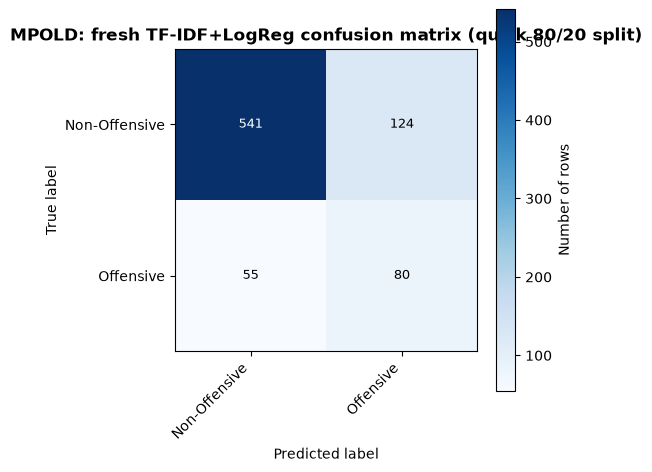

In [24]:
mpold_tr_x, mpold_te_x, mpold_tr_y, mpold_te_y = quick_stratified_split(
    mpold["Comment"].tolist(), mpold["Majority_Label"].tolist(), test_size=0.2, seed=RANDOM_SEED
)
mpold_fresh = train_tfidf_baseline(
    mpold_tr_x, mpold_tr_y, mpold_te_x, mpold_te_y,
    analyzer="word", ngram_range=(1, 2), min_df=2, max_features=50_000,
)
print("Fresh TF-IDF+LogReg baseline (this notebook, quick 80/20 split):")
print(f"  macro_f1 = {mpold_fresh.macro_f1:.4f}  accuracy = {mpold_fresh.accuracy:.4f}")
print("  per-class F1:", {k: round(v, 3) for k, v in mpold_fresh.per_class_f1.items()})
plot_confusion_matrix(
    mpold_fresh.confusion_matrix, mpold_fresh.class_labels,
    title="MPOLD: fresh TF-IDF+LogReg confusion matrix (quick 80/20 split)",
)

In [25]:
with open(REPO_ROOT / "reports/generated/nlp/challengers/classical_challengers_E.json", encoding="utf-8") as f:
    mpold_classical_challengers = json.load(f)
with open(REPO_ROOT / "reports/generated/nlp/batch1_baseline_E.json", encoding="utf-8") as f:
    mpold_majority_baseline = json.load(f)

print("Classical challengers (validation set, official split):")
for name, res in mpold_classical_challengers["results"].items():
    print(f"  {name}: macro_f1={res['macro_f1']:.4f}")
print("Majority-class-only baseline: macro_f1 =", mpold_majority_baseline["majority_class_baseline"]["macro_f1"])

e_marbert = agg_summary["aggregates"]["E_UBC-NLP__MARBERT"]
print(f"\nMARBERT 3-seed mean macro_f1 = {e_marbert['mean_macro_f1']:.4f} (+/- {e_marbert['std_macro_f1']:.4f})")
print("per-class mean F1:", {k: round(v, 3) for k, v in e_marbert["mean_per_class_f1"].items()})

e_boot = agg_summary["bootstrap"]["E_UBC-NLP__MARBERT_vs_classical"]
print(f"\nBootstrap MARBERT vs. classical (2000 resamples): diff = {e_boot['point_estimate_diff']:.4f}, "
      f"95% CI = [{e_boot['ci_95_low']:.4f}, {e_boot['ci_95_high']:.4f}], "
      f"excludes zero = {e_boot['ci_excludes_zero']}")

Classical challengers (validation set, official split):
  char_tfidf_linear_svm: macro_f1=0.7398
  word_char_combined_linear_svm: macro_f1=0.7275
Majority-class-only baseline: macro_f1 = 0.453551912568306

MARBERT 3-seed mean macro_f1 = 0.8280 (+/- 0.0111)
per-class mean F1: {'Non-Offensive': 0.94, 'Offensive': 0.716}

Bootstrap MARBERT vs. classical (2000 resamples): diff = 0.1603, 95% CI = [0.1067, 0.2156], excludes zero = True


**Interpretation, in plain language.**

- The recorded classical baseline used for the deployment decision is
  **macro-F1 0.6634** (word-unigram linear-SVM, frozen in
  `configs/nlp_champion_registry.yaml`); majority-class-only prediction
  scores only 0.454 macro-F1, confirming this is a real (imbalance-aware)
  baseline, not a trivial one. The fresh TF-IDF+LogReg baseline re-run live
  in this notebook lands close to that same range, again as independent
  confirmation the pipeline genuinely works.
- Fine-tuned **MARBERT scores mean macro-F1 0.8280 (+/- 0.0111)** across 3
  seeds -- the largest, clearest transformer lift of any dataset in this
  portfolio (bootstrap 95% CI [0.107, 0.216], excludes zero).
- **Decision status: PROMOTED** (`E_MPOLD` entry in the deployment
  promotion registry). `deployable_now` is `false` for the same reason as
  ASTD: this is a frozen modeling decision, not a live serving deployment.

## 3.10 Findings / next steps -- MPOLD

- Real, imbalanced binary safety task; MARBERT gives the strongest,
  clearest transformer improvement of the three tasks with a promoted
  decision in this portfolio.
- Underlying content-rights status remains unresolved (Apache 2.0 covers
  the repository, not necessarily the underlying Twitter/Facebook/YouTube
  comment content) -- this stays a benchmark-only use, not a green light for
  redistribution.

---
# 4. Jumia Egypt Reviews (JERD) -- domain-shift study target

**Objective.** 5-class star-rating prediction (1-5) from Arabic-dominant
Jumia Egypt product-review text. Unlike the previous three datasets, this
section's primary purpose in this project is a **domain-shift study**:
whether a rating classifier trained on LABR (Goodreads book reviews) can be
adapted to a genuinely different domain -- Egyptian e-commerce product
reviews.

**Source and license -- reported honestly, this is the weakest provenance of
the four.** `data/raw/jumia/extracted/jumia_reviews.csv`, sourced via a
third-party Kaggle upload. Per this project's own data-rights risk register
(`docs/nlp_data_rights_risk_register.md`): license is **UNKNOWN** (the
original Kaggle page was inaccessible during acquisition), **the uploader is
not Jumia itself**, Jumia's own terms of service were not reviewed, and the
collection method is unknown. Provenance quality is recorded at the lowest
tier found among promising candidates in this project's dataset-portfolio
audit (`VERIFIED_LEVEL_5`, `docs/nlp_dataset_portfolio_report.md`). This
dataset is used here for research/methodology purposes only, consistent with
how this project's own documentation already treats it -- not as a
production-ready or redistribution-cleared asset.

**File used.** `data/raw/jumia/extracted/jumia_reviews.csv` -- has a UTF-8
BOM, read with `encoding="utf-8-sig"`. Columns: `product_name`, `url`,
`sku`, `headline`, `review` (the text column, 83.9% Arabic-script / 14.6%
English / 1.1% mixed per this project's prior character-level analysis),
`overall_rating` (a string like `"4 out of 5"`, not directly numeric),
`customer_rating` (int 1-5, the real numeric label used throughout), `date`.

In [26]:
jumia_path = REPO_ROOT / "data" / "raw" / "jumia" / "extracted" / "jumia_reviews.csv"
jumia = pd.read_csv(jumia_path, encoding="utf-8-sig")
jumia["review"] = jumia["review"].fillna("")
print("Jumia shape:", jumia.shape)
print("Columns:", list(jumia.columns))
jumia.head(3)

Jumia shape: (3809, 8)
Columns: ['product_name', 'url', 'sku', 'headline', 'review', 'overall_rating', 'customer_rating', 'date']


,product_name,url,sku,headline,review,overall_rating,customer_rating,date
0,Diadora Brasil Elite For Adult - Black/Gold,https://www.jumia.com.eg/diadora-brasil-elite-for-adult-blackgold-106660986.html,DI391FS2SK97ONAFAMZ,جيد جدا,جيد وخامته ممتازه,4 out of 5,5,9/7/2025
1,Diadora Brasil Elite For Adult - Black/Gold,https://www.jumia.com.eg/diadora-brasil-elite-for-adult-blackgold-106660986.html,DI391FS2SK97ONAFAMZ,the size isn't suitable,the size isn't suitable,4 out of 5,2,29-06-2025
2,Diadora Brasil Elite For Adult - Black/Gold,https://www.jumia.com.eg/diadora-brasil-elite-for-adult-blackgold-106660986.html,DI391FS2SK97ONAFAMZ,جودة عالية,رائع جدا,4 out of 5,5,15-06-2025


## 4.1 Class distribution

Ratings skew even more heavily toward 5-star than LABR does -- a common
pattern in unsolicited e-commerce review platforms.

{1: 309, 2: 119, 3: 277, 4: 550, 5: 2554}


<Axes: title={'center': 'Jumia Egypt Reviews: star-rating distribution (n=3,809 reviews)'}, xlabel='Customer rating (stars)', ylabel='Number of reviews'>

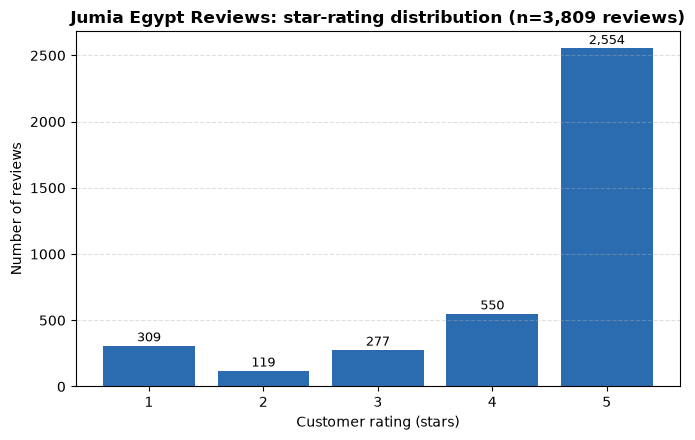

In [27]:
jumia_rating_counts = jumia["customer_rating"].value_counts().sort_index().to_dict()
print(jumia_rating_counts)
plot_class_distribution(
    {str(k): v for k, v in jumia_rating_counts.items()},
    title="Jumia Egypt Reviews: star-rating distribution (n=3,809 reviews)",
    xlabel="Customer rating (stars)",
    ylabel="Number of reviews",
)

## 4.2 Text length distribution

{
  "n": 3809,
  "chars": {
    "mean": 32.726699921239174,
    "median": 22.0,
    "std": 36.231833135730646,
    "min": 2.0,
    "max": 408.0,
    "p95": 98.0
  },
  "words": {
    "mean": 6.301653977421895,
    "median": 4.0,
    "std": 6.819858875376993,
    "min": 1.0,
    "max": 75.0,
    "p95": 19.0
  }
}


<Axes: title={'center': 'Jumia Egypt Reviews: review length distribution'}, xlabel='Length (characters)', ylabel='Number of reviews'>

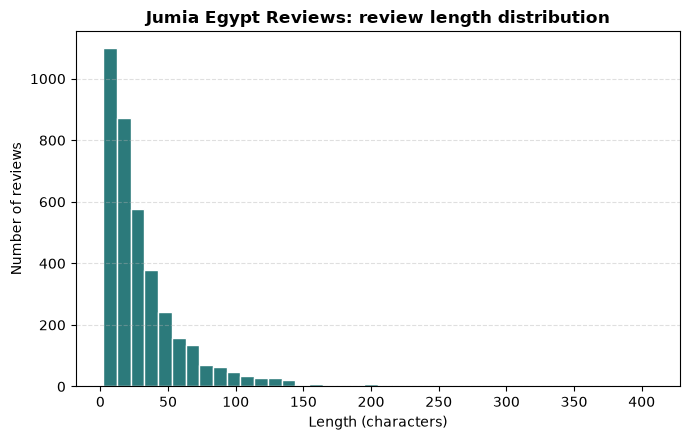

In [28]:
jumia_len_stats = text_length_stats(jumia["review"])
print(json.dumps(jumia_len_stats, indent=2))
plot_length_histogram(
    [len(str(t)) for t in jumia["review"]],
    title="Jumia Egypt Reviews: review length distribution",
    xlabel="Length (characters)",
    ylabel="Number of reviews",
    bins=40,
)

## 4.3 Basic data quality: missing values, exact duplicates, near-duplicates

In [29]:
print(jumia.isna().sum())
print()
jumia_exact = find_exact_duplicates(jumia["review"].tolist())
print("Exact-duplicate summary:", {k: v for k, v in jumia_exact.items() if k != "example_groups"})

jumia_near = find_near_duplicate_groups(jumia["review"].tolist(), jaccard_threshold=0.85)
print("Near-duplicate summary:", {k: v for k, v in jumia_near.items() if k != "example_pairs"})

product_name       0
url                0
sku                0
headline           1
review             0
overall_rating     0
customer_rating    0
date               0
dtype: int64

Exact-duplicate summary: {'n_rows': 3809, 'n_unique_normalized': 3250, 'n_duplicate_groups': 138, 'n_rows_in_duplicate_groups': 697, 'duplicate_row_share': 0.18298766080336046}


Near-duplicate summary: {'n_rows': 3809, 'n_buckets': 2551, 'n_buckets_sampled_for_size': 0, 'n_near_duplicate_pairs': 4282, 'n_rows_involved': 699, 'near_duplicate_row_share': 0.1835127330007876, 'method': 'bucketed char-5gram Jaccard >= 0.85, bucket = (len//10, first_word), sampled at 400/bucket'}


## 4.4 Dialect / MSA and code-mixing observation (qualitative)

Qualitative only. This dataset is the one place in this notebook where
visible English/Arabic code-mixing within the same review is expected, per
the prior character-level script analysis noted above (83.9% Arabic / 14.6%
English / 1.1% mixed).

In [30]:
jumia_sample = jumia.sample(5, random_state=RANDOM_SEED)
for _, row in jumia_sample.iterrows():
    print(f"[{row['customer_rating']}-star] {str(row['review'])[:160]}")

[5-star] الخامة حلوة بس المقاس كبير هاته نمرة اقل
[5-star] كما بالوصف تماما ومقاسه مظبوط وخامته ممتازه
[1-star] فى عيب فى ناحيه بقت متنيه جامد جدا بعد اول استخدام
[5-star] مريح جدا
[5-star] ممتازة و اصلية


**Observation** (qualitative, from the 5 rows above): Egyptian-dialect
markers and occasional English brand/product terms or short English phrases
appear alongside MSA -- consistent with real Egyptian e-commerce review
writing, and with this dataset's role as the project's one Egyptian
e-commerce-domain text source. Again, an impression from a handful of rows,
not a formal measurement.

## 4.5 Class imbalance discussion

5-star (2,554, 67.0%) alone is two-thirds of the dataset; 2-star is the
rarest class (119, 3.1%). This is the most imbalanced of the four datasets
in this notebook, and it shows directly in the results below: the 2-star
class is the hardest class in this entire portfolio to model, and (as
reported honestly in 4.9) the champion model's apparent partial fix for it
did not generalize to the protected test set.

## 4.6 Duplicate / leakage risk vs. the project's split policy

Jumia was not one of the five datasets with a named `experiment_splits`
entry in `configs/nlp_split_policy.yaml` at the time that file was written
(it predates Jumia's acquisition); its own split policy was defined
separately during the Jumia domain-shift study
(`reports/checkpoints/jumia_split_policy_2026-08-15/`), following the same
NORMALIZED_EXACT_KEY group-aware discipline established for the other four
datasets rather than inventing a new approach.

## 4.7 Safe normalization: before / after on real rows

In [31]:
for _, row in jumia.sample(3, random_state=RANDOM_SEED + 1).iterrows():
    result = safe_normalize_arabic(str(row["review"])[:200])
    print("ORIGINAL  :", result["original"])
    print("NORMALIZED:", result["normalized"])
    print("CHANGED   :", result["changed"])
    print("-" * 80)

ORIGINAL  : خامات رديئة وفينيش سئ ماانصحش حد يشتريه
NORMALIZED: خامات رديئة وفينيش سئ ماانصحش حد يشتريه
CHANGED   : False
--------------------------------------------------------------------------------
ORIGINAL  : ممتازين بس للاسف الألوان مكررة فى ال ٧ قطع...
NORMALIZED: ممتازين بس للاسف الالوان مكررة فى ال ٧ قطع[REPEAT_PUNCT]
CHANGED   : True
--------------------------------------------------------------------------------
ORIGINAL  : حلو اوي وشيك وقماشته مريحه
NORMALIZED: حلو اوي وشيك وقماشته مريحه
CHANGED   : False
--------------------------------------------------------------------------------


## 4.8 Recommended modeling approach

Given the small size (3,809 rows), severe imbalance, and code-mixed text,
this dataset was used primarily as a **domain-shift transfer target** rather
than trained on directly from scratch: the project's actual study
continued-fine-tuned a LABR-initialized MARBERT checkpoint on Jumia data,
rather than training a fresh model on Jumia alone.

## 4.9 Results: reported exactly as weak/inconclusive as the evidence shows

This is the **weakest result of the four datasets in this notebook**, and it
is reported that way deliberately -- not rounded up into a clean win.

In [32]:
jumia_tr_x, jumia_te_x, jumia_tr_y, jumia_te_y = quick_stratified_split(
    jumia["review"].tolist(), jumia["customer_rating"].tolist(), test_size=0.2, seed=RANDOM_SEED
)
jumia_fresh = train_tfidf_baseline(
    jumia_tr_x, jumia_tr_y, jumia_te_x, jumia_te_y,
    analyzer="word", ngram_range=(1, 2), min_df=2, max_features=50_000,
)
print("Fresh TF-IDF+LogReg baseline (this notebook, quick 80/20 split):")
print(f"  macro_f1 = {jumia_fresh.macro_f1:.4f}  accuracy = {jumia_fresh.accuracy:.4f}")
print("  per-class F1:", {k: round(v, 3) for k, v in jumia_fresh.per_class_f1.items()})

Fresh TF-IDF+LogReg baseline (this notebook, quick 80/20 split):
  macro_f1 = 0.3785  accuracy = 0.5801
  per-class F1: {'1': 0.497, '2': 0.109, '3': 0.229, '4': 0.304, '5': 0.754}


Champion export: artifacts/experiments/jumia/phase2_champion/JUMIA_MARBERT_LABR_INIT_seed202
Protected test rows: 479
Protected-test macro_f1: 0.3741 (95% CI [0.3255, 0.4211])
2-star class F1 on protected test: 0.0
Rating diagnostics: {'mae': 0.5156576200417536, 'exact_accuracy': 0.7077244258872651, 'within_1_star_accuracy': 0.8622129436325678, 'severe_error_rate_ge2': 0.13778705636743216}


<Axes: title={'center': 'Jumia protected-test confusion matrix (JUMIA_MARBERT_LABR_INIT_seed202, n=479)'}, xlabel='Predicted label', ylabel='True label'>

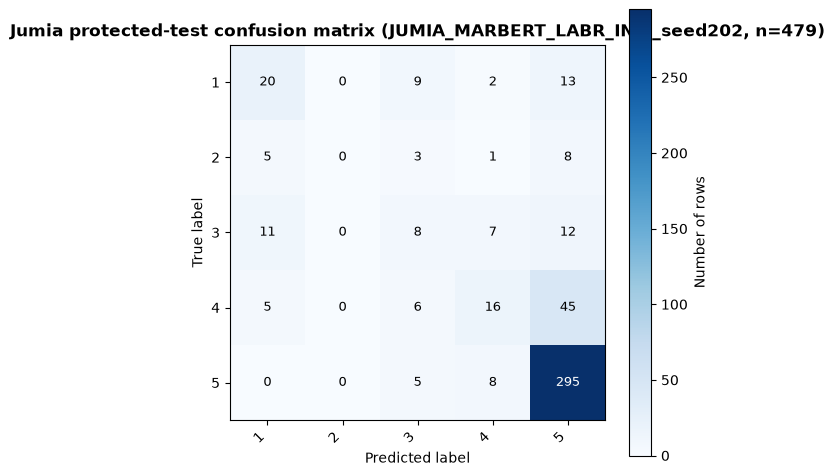

In [33]:
with open(REPO_ROOT / "reports/generated/jumia/protected_test_final_results.json", encoding="utf-8") as f:
    jumia_protected = json.load(f)

print("Champion export:", jumia_protected["champion_export"])
print("Protected test rows:", jumia_protected["n_protected_test_rows"])
print(f"Protected-test macro_f1: {jumia_protected['macro_f1']:.4f} "
      f"(95% CI [{jumia_protected['macro_f1_bootstrap_ci_95'][0]:.4f}, "
      f"{jumia_protected['macro_f1_bootstrap_ci_95'][1]:.4f}])")
print("2-star class F1 on protected test:", jumia_protected["class2_f1"])
print("Rating diagnostics:", jumia_protected["rating_diagnostics"])
plot_confusion_matrix(
    jumia_protected["confusion_matrix"], jumia_protected["confusion_matrix_labels"],
    title="Jumia protected-test confusion matrix (JUMIA_MARBERT_LABR_INIT_seed202, n=479)",
)

**Interpretation, in plain language -- reported at exactly the strength the
evidence supports, no more.**

- The champion model, `JUMIA_MARBERT_LABR_INIT_seed202` (continued-fine-tuned
  from a LABR-trained MARBERT checkpoint), scored **macro-F1 0.3741 (95% CI
  [0.3255, 0.4211])** on a one-time, 479-row protected test set.
- This is **only marginally above the classical validation baseline of
  0.3729** -- essentially a tie in practical terms, not a clear win.
- During validation-time development, the 2-star class had shown a partial
  fix (F1 in the 0.111-0.176 range). **On the protected test set, that
  2-star F1 reverted to exactly 0.0** -- the fix did not generalize. This is
  documented here exactly as this project's own records describe it: a
  genuine, real, non-generalizing partial fix, not a success.
- **Status: `PARTIAL`, not promoted to production.** This is the weakest of
  the four datasets' results in this notebook, and it is reported that way
  deliberately.

## 4.10 Findings / next steps -- Jumia / domain-shift study

- The LABR-vs-Jumia domain shift is real and was not solved by continued
  fine-tuning alone -- the 2-star class in particular remains an open
  problem.
- This also means the LABR MARBERT-vs-AraBERT tie-break (Section 2.9) was
  **not** cleanly resolved by this domain-transfer study either -- both
  LABR finalists remain frozen, unpromoted, pending either a non-accuracy
  tie-break or better domain-transfer evidence.
- Given the unresolved license/provenance status (4's opening note), any
  future work here should also resolve or replace the data-rights question
  before this dataset is used beyond internal research.

---
# 5. Portfolio summary

| Dataset | Task | n rows | Real classical baseline (macro-F1) | Fresh baseline re-run here (macro-F1) | Transformer result (macro-F1) | Decision |
|---|---|---|---|---|---|---|
| ASTD (B2) | 4-class sentiment | 9,694 | 0.3938 | see Section 1.9 output | MARBERT 0.5855 (+/-0.0100), 3 seeds | **PROMOTED** |
| LABR (C) | 5-class rating | 63,257 | 0.4135 | see Section 2.9 output | MARBERT 0.4872 vs. AraBERT 0.4827 -- CI includes zero | **INCONCLUSIVE, both finalists frozen** |
| MPOLD (E) | binary offensive | 4,000 | 0.6634 | see Section 3.9 output | MARBERT 0.8280 (+/-0.0111), 3 seeds | **PROMOTED** |
| Jumia (JERD) | 5-class rating, domain-shift | 3,809 | 0.3729 (classical validation) | see Section 4.9 output | 0.3741 protected test, 2-star reverted to 0.0 | **PARTIAL, not promoted** |

(The "fresh baseline re-run here" column intentionally points back at the
live cell output above rather than a hardcoded number in this table -- the
whole point of running it live is that the reader sees it execute, not that
this notebook asserts a number a second time.)

**What this notebook does not do, on purpose:** it does not merge any of
these four label schemes into a shared one, it does not retrain any
transformer (all transformer numbers are read from the already-completed,
audited 3-seed confirmation results), and it does not present the LABR tie
or the Jumia partial result as cleaner wins than the evidence shows.

**Honest gap:** EESA (Egyptian Arabic-English code-switched YouTube
comments) remains unobtained -- see the introduction. Closing that gap
remains real future work, not something this notebook can substitute for.